# Stan Comparison For Gaussian K=2 Rolling-Standardized HMM

This notebook uses the same local Stan workflow from pset 5 to build a Stan baseline for the rolling-standardized `K = 2` Gaussian HMM.

Important note: to keep Stan stable and identifiable, this Stan model uses diagonal Gaussian state covariances with ordered overall volatility levels. So it is a close comparison baseline for the new simplified model family, but it is not a literal full-covariance replica of the Python sampler notebook.

## Why this should work from pset 5

Your pset 5 notebook already set up the key pieces we need:
- `cmdstanpy`
- local CmdStan path detection on macOS
- `CmdStanModel(...)` compilation and sampling from a notebook

So yes, the pset 5 Stan workflow is enough to run a Stan implementation here too.

## Local environment reminder

This notebook assumes the same kind of environment as pset 5. If `cmdstanpy` is missing in your kernel, install it first with something like:

```python
%pip install cmdstanpy arviz xarray pandas matplotlib numpy
```

If CmdStan itself is not installed, use the setup instructions near the top of [diegolggpset5.ipynb](/Users/diego/Stat%20221/diegolggpset5.ipynb).

In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel, cmdstan_path
from IPython.display import display

In [15]:
# troubleshooting since I couldn't figure out how to get Stan to work without forcing hierarchical_py manually

import sys
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

env_prefix = Path(sys.executable).resolve().parents[1]
cmdstan_dir = env_prefix / "bin" / "cmdstan"

print("python:", sys.executable)
print("trying cmdstan at:", cmdstan_dir)

set_cmdstan_path(str(cmdstan_dir))
print("cmdstan_path():", cmdstan_path())

from cmdstanpy import CmdStanModel
model = CmdStanModel(stan_file="hierarchical_py.stan")

python: /opt/anaconda3/envs/stat221-ps5/bin/python
trying cmdstan at: /opt/anaconda3/envs/stat221-ps5/bin/cmdstan
cmdstan_path(): /opt/anaconda3/envs/stat221-ps5/bin/cmdstan


## CmdStan environment helpers from pset 5

These are adapted directly from the pset 5 notebook so local compilation behaves the same way on macOS.

In [3]:
def detect_macos_sdkroot() -> str | None:
    xcrun = shutil.which('xcrun')
    if xcrun is not None:
        try:
            result = subprocess.run([xcrun, '--show-sdk-path'], check=True, capture_output=True, text=True)
            sdkroot = Path(result.stdout.strip())
            if sdkroot.exists():
                return str(sdkroot)
        except (OSError, subprocess.SubprocessError):
            pass

    candidate_roots = [
        Path('/Library/Developer/CommandLineTools/SDKs'),
        Path('/Applications/Xcode.app/Contents/Developer/Platforms/MacOSX.platform/Developer/SDKs'),
    ]
    for root in candidate_roots:
        if not root.exists():
            continue
        candidates = sorted(root.glob('MacOSX*.sdk'), reverse=True)
        if candidates:
            return str(candidates[0])
    return None


def find_cmdstan_home() -> Path | None:
    env_cmdstan = os.environ.get('CMDSTAN')
    if env_cmdstan:
        path = Path(env_cmdstan).expanduser()
        if path.exists():
            return path

    try:
        path = Path(cmdstan_path())
        if path.exists():
            return path
    except Exception:
        pass

    cmdstan_root = Path.home() / '.cmdstan'
    if not cmdstan_root.exists():
        return None

    candidates = sorted([path for path in cmdstan_root.glob('cmdstan-*') if path.is_dir()], key=lambda path: path.name, reverse=True)
    return candidates[0] if candidates else None


def configure_cmdstan_environment() -> None:
    env_bin = Path(sys.executable).resolve().parent
    current_path = os.environ.get('PATH', '')
    path_entries = current_path.split(os.pathsep) if current_path else []
    if str(env_bin) not in path_entries:
        os.environ['PATH'] = f"{env_bin}{os.pathsep}{current_path}" if current_path else str(env_bin)

    make_path = shutil.which('make')
    if make_path is not None:
        os.environ.setdefault('MAKE', make_path)

    sdkroot = detect_macos_sdkroot()
    if sdkroot is not None:
        os.environ.setdefault('SDKROOT', sdkroot)
        os.environ.setdefault('CONDA_BUILD_SYSROOT', sdkroot)

    cmdstan_home = find_cmdstan_home()
    if cmdstan_home is not None:
        os.environ.setdefault('CMDSTAN', str(cmdstan_home))


configure_cmdstan_environment()
print('python:', sys.executable)
print('CMDSTAN:', os.environ.get('CMDSTAN', '<not found>'))

python: /opt/anaconda3/envs/stat221-ps5/bin/python
CMDSTAN: <not found>


## Local data loading and rolling standardization

This mirrors the preprocessing we used in the healthier Gaussian `K = 2` experiments.

In [7]:
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'crypto_stage1_processed'
STAN_FILE = PROJECT_DIR / 'gaussian_k2_rollstd_hmm.stan'
COMPARE_ROOT = DATA_DIR / 'gaussian_k2_rollstd_comparison'
OUT_DIR = DATA_DIR / 'stan_k2_rollstd_comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_table_path(base_path) -> Path:
    base = Path(base_path)
    candidates = [base] if base.suffix in {'.parquet', '.pkl'} else [base.with_suffix('.parquet'), base.with_suffix('.pkl')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No saved table found for {base}')


def read_table(base_path) -> pd.DataFrame:
    path = resolve_table_path(base_path)
    if path.suffix == '.parquet':
        return pd.read_parquet(path)
    if path.suffix == '.pkl':
        return pd.read_pickle(path)
    raise ValueError(f'Unsupported table suffix: {path.suffix}')


returns = read_table(DATA_DIR / 'returns_daily').copy()
RET_COLS = [c for c in returns.columns if c.endswith('_ret')]
ROLL_WINDOW = 30
roll_mean = returns[RET_COLS].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).mean()
roll_std = returns[RET_COLS].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).std()
returns_rollstd = returns[['date']].copy()
returns_rollstd[RET_COLS] = (returns[RET_COLS] - roll_mean) / roll_std
returns_rollstd = returns_rollstd.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

Y = returns_rollstd[RET_COLS].to_numpy(dtype=float)
dates = pd.to_datetime(returns_rollstd['date']).reset_index(drop=True)
T, d = Y.shape
K = 2

print('Stan data shape:', Y.shape)
display(returns_rollstd.head())

Stan data shape: (1994, 5)


,date,BTC_ret,ETH_ret,SOL_ret,BNB_ret,AVAX_ret
0,2020-10-22 00:00:00+00:00,0.399121,1.708647,0.830119,0.641052,0.923310
1,2020-10-23 00:00:00+00:00,-0.623360,-0.728717,0.217990,-0.304456,-0.335798
2,2020-10-24 00:00:00+00:00,0.473779,0.078759,-0.118305,-0.216738,-0.254969
3,2020-10-25 00:00:00+00:00,-0.781368,-0.852888,-0.825982,-0.796929,-0.070919
4,2020-10-26 00:00:00+00:00,-0.285961,-1.499867,-0.778629,0.836527,0.052243


## Stan data and sampling configuration

These defaults are meant to be a practical comparison run, not a heroic overnight fit. If this behaves well, you can scale `ITER_WARMUP` and `ITER_SAMPLING` upward.

In [10]:
stan_data = {
    'T': int(T),
    'd': int(d),
    'K': int(K),
    'Y': Y,
    'mu_prior_scale': np.repeat(0.5, d),
    'trans_conc': 4.0,
    'log_sigma_sd': 0.5,
    'z_sigma_sd': 0.25,
}

STAN_CHAINS = 2
STAN_PARALLEL_CHAINS = 2
ITER_WARMUP = 250
ITER_SAMPLING = 250
ADAPT_DELTA = 0.9
MAX_TREEDEPTH = 11
REFRESH = 25

print({
    'chains': STAN_CHAINS,
    'iter_warmup': ITER_WARMUP,
    'iter_sampling': ITER_SAMPLING,
    'adapt_delta': ADAPT_DELTA,
    'max_treedepth': MAX_TREEDEPTH,
})

{'chains': 2, 'iter_warmup': 250, 'iter_sampling': 250, 'adapt_delta': 0.9, 'max_treedepth': 11}


## Compile the Stan model

This uses the dedicated Stan file created for this comparison notebook.

In [17]:
model = CmdStanModel(stan_file=str(STAN_FILE))
print('compiled:', STAN_FILE)

15:51:10 - cmdstanpy - INFO - compiling stan file /var/folders/8k/41v7gwyd5v19fw_03n7k8fym0000gn/T/tmpw_fr3yz9/tmp_uiuytd7.stan to exe file /Users/diego/Stat 221/gaussian_k2_rollstd_hmm
15:51:20 - cmdstanpy - INFO - compiled model executable: /Users/diego/Stat 221/gaussian_k2_rollstd_hmm


compiled: /Users/diego/Stat 221/gaussian_k2_rollstd_hmm.stan


## Sample with Stan NUTS

This is the main Stan run. It will take longer than the lightweight stochastic-gradient pilots, but it gives us a clean NUTS baseline for comparison.

In [19]:
fit = model.sample(
    data=stan_data,
    chains=STAN_CHAINS,
    parallel_chains=STAN_PARALLEL_CHAINS,
    iter_warmup=ITER_WARMUP,
    iter_sampling=ITER_SAMPLING,
    adapt_delta=ADAPT_DELTA,
    max_treedepth=MAX_TREEDEPTH,
    refresh=REFRESH,
    show_console=True,
)

fit.save_csvfiles(dir=str(OUT_DIR / 'csv'))
print('saved csv files to', OUT_DIR / 'csv')

15:51:22 - cmdstanpy - INFO - Chain [1] start processing
15:51:22 - cmdstanpy - INFO - Chain [2] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 250
Chain [1] num_warmup = 250
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.9
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 11
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/8k/41v7gwyd5v19fw_03n7k8fym0000gn/T/tmpxdxzfs0a/d6fzm7ap.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 98281
Chai

15:51:50 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 500 / 500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 16.509 seconds (Warm-up)
Chain [2] 10.919 seconds (Sampling)
Chain [2] 27.428 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [1] Iteration: 375 / 500 [ 75%]  (Sampling)
Chain [1] Iteration: 400 / 500 [ 80%]  (Sampling)
Chain [1] Iteration: 425 / 500 [ 85%]  (Sampling)
Chain [1] Iteration: 450 / 500 [ 90%]  (Sampling)
Chain [1] Iteration: 475 / 500 [ 95%]  (Sampling)


15:52:02 - cmdstanpy - INFO - Chain [1] done processing
15:52:02 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but m

Chain [1] Iteration: 500 / 500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 19.159 seconds (Warm-up)
Chain [1] 19.932 seconds (Sampling)
Chain [1] 39.091 seconds (Total)
Chain [1] 
Chain [1] 
saved csv files to /Users/diego/Stat 221/crypto_stage1_processed/stan_k2_rollstd_comparison/csv


## Stan diagnostics summary

This gives the standard NUTS diagnostics and posterior summaries for the main parameters.

In [21]:
stan_summary = fit.summary()
stan_summary.to_csv(OUT_DIR / 'stan_summary.csv')
display(stan_summary.head(30))

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-12920.600000,0.270006,3.403330,3.192780,-12927.200000,-12920.200000,-12915.600000,152.7320,303.032,4.95062,1.00880
"A[1,1]",0.683168,0.001351,0.020598,0.022619,0.647987,0.684384,0.713712,242.8880,275.939,7.87294,1.01024
"A[1,2]",0.316832,0.001351,0.020598,0.022619,0.286288,0.315616,0.352013,242.8880,275.939,7.87294,1.01023
"A[2,1]",0.463036,0.001233,0.024455,0.024897,0.423092,0.462623,0.504714,396.8590,392.026,12.86370,1.00445
"A[2,2]",0.536964,0.001233,0.024455,0.024897,0.495286,0.537377,0.576908,396.8590,392.026,12.86370,1.00440
log_sigma_level[1],-0.554245,0.015923,0.112916,0.123621,-0.744986,-0.553000,-0.370493,47.6119,243.093,1.54329,1.03997
log_sigma_level[2],0.342635,0.010613,0.109495,0.107375,0.146407,0.344472,0.515138,104.5110,284.869,3.38762,1.00777
"mu[1,1]",0.072708,0.002217,0.029090,0.029966,0.025856,0.073416,0.121183,172.5690,250.000,5.59362,1.00994
"mu[1,2]",0.087463,0.002049,0.025344,0.024434,0.042063,0.088356,0.127168,168.2820,250.446,5.45465,1.00957
"mu[1,3]",0.042772,0.002080,0.028667,0.028744,-0.007437,0.043111,0.088192,195.4520,284.880,6.33535,1.00489


## Extract interpretable posterior summaries

We focus on the regime persistence, stationary distribution, means, and volatility levels.

In [23]:
A_draws = fit.stan_variable('A')              # (draw, K, K)
pi_draws = fit.stan_variable('pi')            # (draw, K)
mu_draws = fit.stan_variable('mu')            # (draw, K, d)
sigma_draws = fit.stan_variable('sigma')      # (draw, K, d)

def summarize_array(name, values):
    flat = np.asarray(values).reshape(-1)
    return {
        'variable': name,
        'mean': float(np.mean(flat)),
        'sd': float(np.std(flat, ddof=1)),
        'q05': float(np.quantile(flat, 0.05)),
        'median': float(np.quantile(flat, 0.50)),
        'q95': float(np.quantile(flat, 0.95)),
    }

posterior_rows = [
    summarize_array('pi_0', pi_draws[:, 0]),
    summarize_array('pi_1', pi_draws[:, 1]),
    summarize_array('A_00', A_draws[:, 0, 0]),
    summarize_array('A_11', A_draws[:, 1, 1]),
    summarize_array('mean_sigma_0', sigma_draws[:, 0, :].mean(axis=1)),
    summarize_array('mean_sigma_1', sigma_draws[:, 1, :].mean(axis=1)),
    summarize_array('mu_0_0', mu_draws[:, 0, 0]),
    summarize_array('mu_1_0', mu_draws[:, 1, 0]),
]
stan_posterior_summary = pd.DataFrame(posterior_rows)
stan_posterior_summary.to_csv(OUT_DIR / 'stan_posterior_summary.csv', index=False)
display(stan_posterior_summary)

,variable,mean,sd,q05,median,q95
0,pi_0,0.593737,0.021030,0.557627,0.595487,0.627727
1,pi_1,0.406263,0.021030,0.372273,0.404513,0.442373
2,A_00,0.683168,0.020598,0.647987,0.684384,0.713712
3,A_11,0.536964,0.024455,0.495286,0.537377,0.576908
4,mean_sigma_0,0.555911,0.012611,0.534476,0.556241,0.575723
5,mean_sigma_1,1.408306,0.022759,1.372789,1.407580,1.446173
6,mu_0_0,0.072708,0.029090,0.025856,0.073416,0.121183
7,mu_1_0,-0.124534,0.060962,-0.222609,-0.122871,-0.025659


## Posterior-mean smoothed state probabilities from Stan

The Stan model already samples `gamma[t, k]`, so here we average those draws to get an interpretable smoothed occupancy profile.

Stan posterior-mean most-likely state shares: [0.62036108 0.37963892]
Stan posterior-mean average smoothed probabilities: [0.59486419 0.40513581]


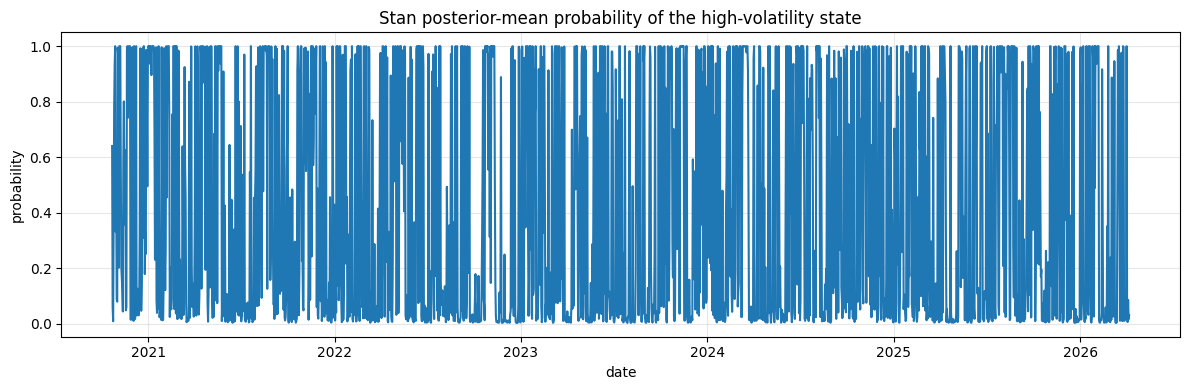

In [25]:
gamma_draws = fit.stan_variable('gamma')      # (draw, T, K)
gamma_mean = gamma_draws.mean(axis=0)
ml_state = gamma_mean.argmax(axis=1)
state_share = np.bincount(ml_state, minlength=K) / len(ml_state)

stan_smoothed_df = pd.DataFrame({
    'date': dates,
    'state_0_prob': gamma_mean[:, 0],
    'state_1_prob': gamma_mean[:, 1],
    'ml_state': ml_state,
})
stan_smoothed_df.to_pickle(OUT_DIR / 'stan_smoothed_state_probs.pkl')

print('Stan posterior-mean most-likely state shares:', state_share)
print('Stan posterior-mean average smoothed probabilities:', gamma_mean.mean(axis=0))

plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(stan_smoothed_df['date']), stan_smoothed_df['state_1_prob'], lw=1.5)
plt.title('Stan posterior-mean probability of the high-volatility state')
plt.xlabel('date')
plt.ylabel('probability')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Crypto paths: actual vs Stan-implied

This view translates the latent-state fit back into something more intuitive for crypto: for each asset, we compare the realized normalized path against the path implied by Stan's posterior-mean next-day return forecast. The red shading marks dates where the high-volatility regime probability is above 50%, so we can see whether the stress regime lines up with recognizable market drawdowns and rebounds.



,asset,corr_actual_vs_implied,mae_daily_log_return,actual_final_index,stan_implied_final_index
1,ETH,0.244593,0.028166,544.174907,583.071944
0,BTC,0.232579,0.020830,544.029478,472.876278
4,AVAX,0.231510,0.041067,223.569534,958.987986
3,BNB,0.225838,0.025526,2050.153197,4989.137657
2,SOL,0.224802,0.041008,4350.082067,5086.552948


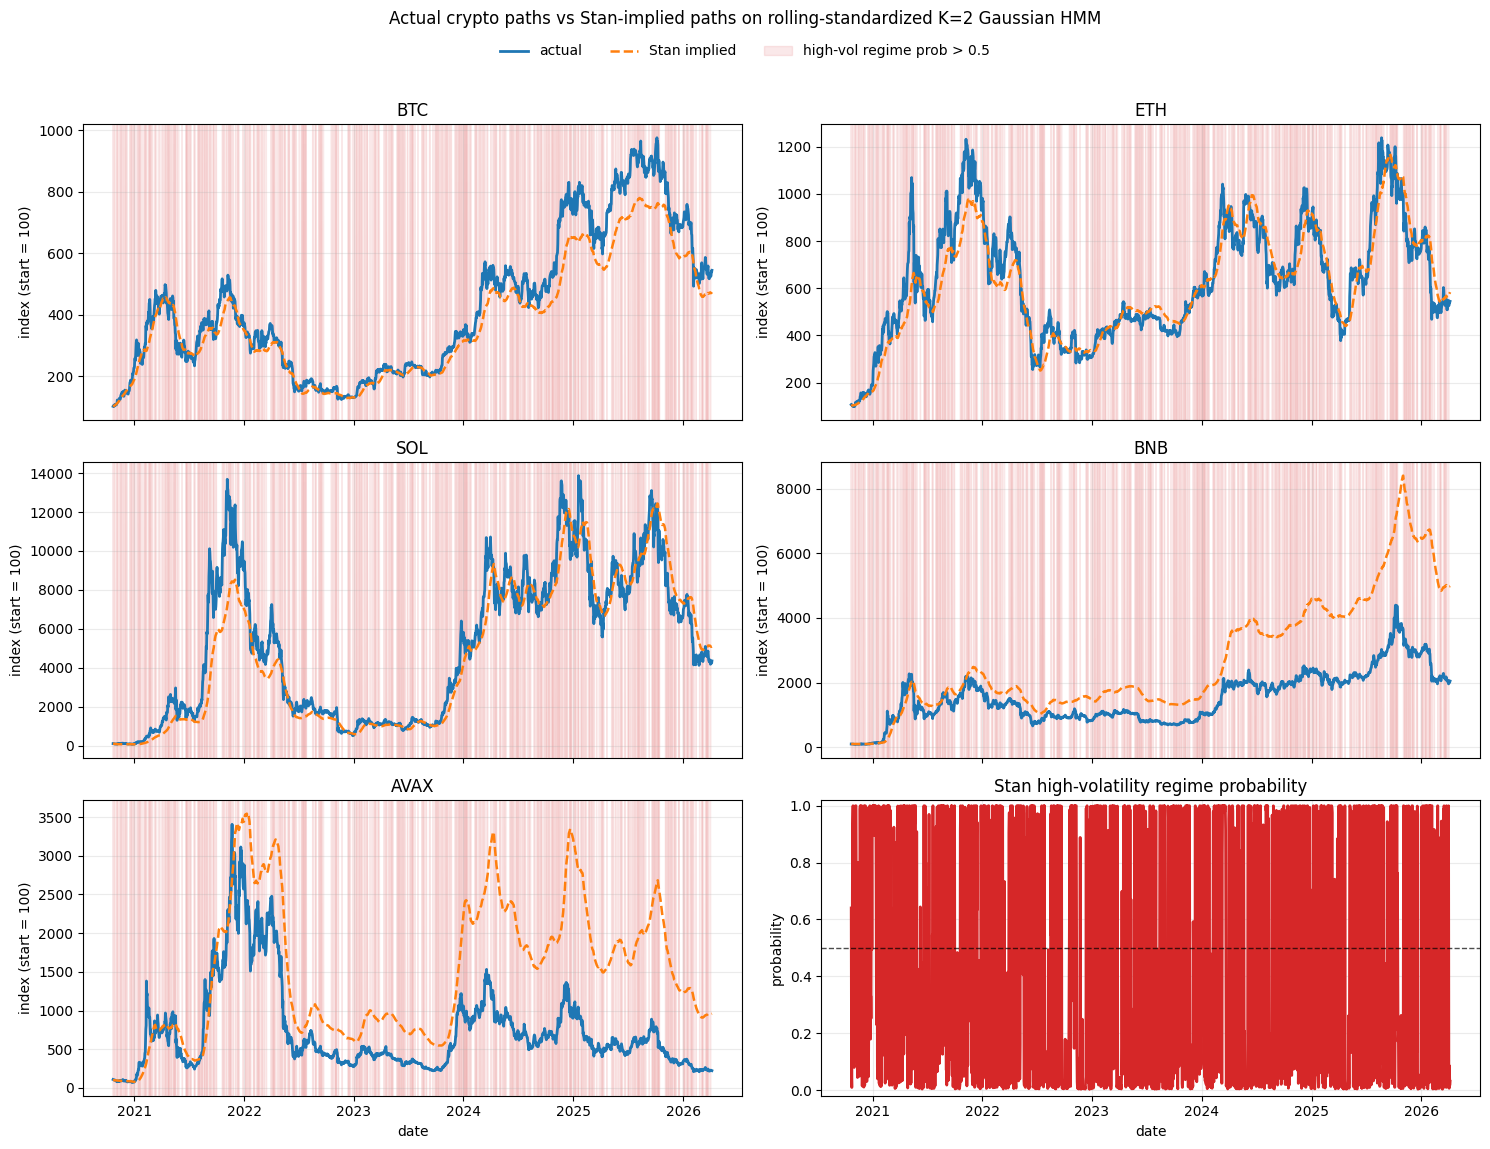

In [29]:
mu_mean = mu_draws.mean(axis=0)                           # (K, d)
expected_std_returns = gamma_mean @ mu_mean               # (T, d)

roll_stats = pd.DataFrame({'date': returns['date']})
for col in RET_COLS:
    roll_stats[f'{col}_roll_mean'] = roll_mean[col].to_numpy()
    roll_stats[f'{col}_roll_std'] = roll_std[col].to_numpy()

plot_df = (
    returns[['date'] + RET_COLS]
    .merge(roll_stats, on='date', how='inner')
    .merge(stan_smoothed_df[['date', 'state_1_prob']], on='date', how='inner')
    .sort_values('date')
    .reset_index(drop=True)
)

roll_mean_cols = [f'{col}_roll_mean' for col in RET_COLS]
roll_std_cols = [f'{col}_roll_std' for col in RET_COLS]

actual_raw_returns = plot_df[RET_COLS].to_numpy(dtype=float)
roll_mean_aligned = plot_df[roll_mean_cols].to_numpy(dtype=float)
roll_std_aligned = plot_df[roll_std_cols].to_numpy(dtype=float)
expected_raw_returns = roll_mean_aligned + roll_std_aligned * expected_std_returns

actual_index = 100.0 * np.exp(np.cumsum(actual_raw_returns, axis=0))
expected_index = 100.0 * np.exp(np.cumsum(expected_raw_returns, axis=0))

asset_labels = [col.replace('_ret', '').upper() for col in RET_COLS]
state_mask = plot_df['state_1_prob'].to_numpy() >= 0.5

fit_rows = []
for j, asset in enumerate(asset_labels):
    corr = np.corrcoef(actual_raw_returns[:, j], expected_raw_returns[:, j])[0, 1]
    mae = np.mean(np.abs(actual_raw_returns[:, j] - expected_raw_returns[:, j]))
    fit_rows.append({
        'asset': asset,
        'corr_actual_vs_implied': float(corr),
        'mae_daily_log_return': float(mae),
        'actual_final_index': float(actual_index[-1, j]),
        'stan_implied_final_index': float(expected_index[-1, j]),
    })

fit_df = pd.DataFrame(fit_rows).sort_values('corr_actual_vs_implied', ascending=False)
display(fit_df)

fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()

for j, asset in enumerate(asset_labels):
    ax = axes[j]
    ax.plot(plot_df['date'], actual_index[:, j], lw=2.0, label='actual')
    ax.plot(plot_df['date'], expected_index[:, j], lw=1.8, ls='--', label='Stan implied')
    y0, y1 = ax.get_ylim()
    ax.fill_between(
        plot_df['date'], y0, y1,
        where=state_mask,
        color='tab:red', alpha=0.10,
        interpolate=True,
        label='high-vol regime prob > 0.5' if j == 0 else None,
    )
    ax.set_ylim(y0, y1)
    ax.set_title(asset)
    ax.set_ylabel('index (start = 100)')
    ax.grid(alpha=0.25)

ax = axes[-1]
ax.plot(plot_df['date'], plot_df['state_1_prob'], color='tab:red', lw=2.0)
ax.axhline(0.5, color='black', ls='--', lw=1.0, alpha=0.7)
ax.set_title('Stan high-volatility regime probability')
ax.set_ylabel('probability')
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)

for ax in axes[-2:]:
    ax.set_xlabel('date')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Actual crypto paths vs Stan-implied paths on rolling-standardized K=2 Gaussian HMM', y=1.04)
fig.tight_layout()
plt.show()



## Optional comparison against the Python Gaussian comparison runs

If you have already run [gaussian_k2_rollstd_comparison.ipynb](/Users/diego/Stat%20221/gaussian_k2_rollstd_comparison.ipynb), this cell will load the latest saved outputs and overlay Stan against `uniform`, `young_static`, and `online_feature`.

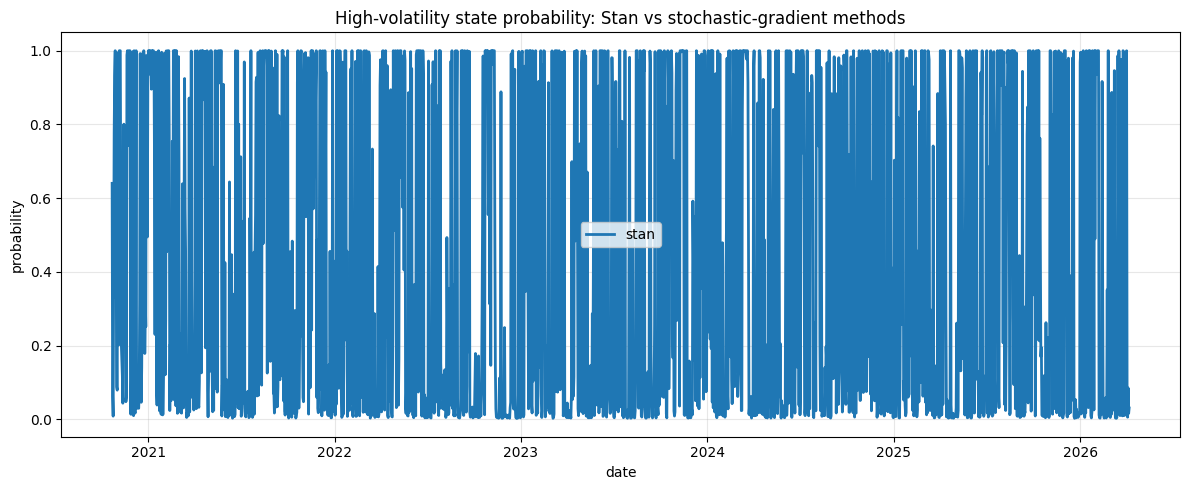

,method,ml_share_state_0,ml_share_state_1,avg_state_0_prob,avg_state_1_prob
0,stan,0.620361,0.379639,0.594864,0.405136


In [27]:
def list_run_dirs(method_root: Path):
    if not method_root.exists():
        return []
    return sorted([p for p in method_root.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)


def latest_run_dir(method_root: Path):
    runs = list_run_dirs(method_root)
    return runs[-1] if runs else None


def load_latest_smoothed(method_name: str):
    method_root = COMPARE_ROOT / method_name
    run_dir = latest_run_dir(method_root)
    if run_dir is None:
        return None, None
    sm_path = run_dir / 'summaries' / 'smoothed_state_probs.pkl'
    if not sm_path.exists():
        return run_dir, None
    return run_dir, pd.read_pickle(sm_path)

compare_methods = ['uniform', 'young_static', 'online_feature']
loaded = {}
for method_name in compare_methods:
    run_dir, sm_df = load_latest_smoothed(method_name)
    loaded[method_name] = {'run_dir': run_dir, 'smoothed': sm_df}

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(stan_smoothed_df['date']), stan_smoothed_df['state_1_prob'], lw=2.0, label='stan')
for method_name in compare_methods:
    sm_df = loaded[method_name]['smoothed']
    if sm_df is not None:
        plt.plot(pd.to_datetime(sm_df['date']), sm_df['state_1_prob'], lw=1.2, label=method_name)
plt.title('High-volatility state probability: Stan vs stochastic-gradient methods')
plt.xlabel('date')
plt.ylabel('probability')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

comparison_rows = [{
    'method': 'stan',
    'ml_share_state_0': float((stan_smoothed_df['ml_state'] == 0).mean()),
    'ml_share_state_1': float((stan_smoothed_df['ml_state'] == 1).mean()),
    'avg_state_0_prob': float(stan_smoothed_df['state_0_prob'].mean()),
    'avg_state_1_prob': float(stan_smoothed_df['state_1_prob'].mean()),
}]
for method_name in compare_methods:
    sm_df = loaded[method_name]['smoothed']
    if sm_df is None:
        continue
    comparison_rows.append({
        'method': method_name,
        'ml_share_state_0': float((sm_df['ml_state'] == 0).mean()),
        'ml_share_state_1': float((sm_df['ml_state'] == 1).mean()),
        'avg_state_0_prob': float(sm_df['state_0_prob'].mean()),
        'avg_state_1_prob': float(sm_df['state_1_prob'].mean()),
    })
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
comparison_df.to_csv(OUT_DIR / 'stan_vs_sg_compare.csv', index=False)

## Readout

If Stan gives a similar occupancy split and similar persistence estimates, that is strong evidence that the rolling-standardized Gaussian `K = 2` model is capturing a real signal and that the stochastic-gradient samplers are not just drifting to an artifact.